In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sales = pd.read_csv("../data/sales_daily.csv")
inventory = pd.read_csv("../data/inventory_snapshots.csv")
sku_master = pd.read_csv("../data/sku_master.csv")

print("Sales Shape:", sales.shape)
print("Inventory Shape:", inventory.shape)
print("SKU Master Shape:", sku_master.shape)

Sales Shape: (36550, 6)
Inventory Shape: (4800, 8)
SKU Master Shape: (50, 8)


In [2]:
sales["Date"] = pd.to_datetime(sales["Date"])

weekly_sales = (
    sales.groupby(
        ["SKU", pd.Grouper(key="Date", freq="W-SUN")]
    )["Units_Sold"]
    .sum()
    .reset_index()
)

weekly_sales = weekly_sales[
    weekly_sales["Date"] < "2026-01-04"
].copy()

print("Weekly Sales Shape:", weekly_sales.shape)
print(weekly_sales.head())

Weekly Sales Shape: (5200, 3)
      SKU       Date  Units_Sold
0  SKU001 2024-01-07         106
1  SKU001 2024-01-14          85
2  SKU001 2024-01-21         117
3  SKU001 2024-01-28          89
4  SKU001 2024-02-04         119


In [3]:
inventory["Snapshot_Date"] = pd.to_datetime(
    inventory["Snapshot_Date"]
)

latest_date = inventory["Snapshot_Date"].max()

latest_inventory = inventory[
    inventory["Snapshot_Date"] == latest_date
].copy()

print("Inventory Reference Date:", latest_date)
print("Latest Inventory Shape:", latest_inventory.shape)
print(latest_inventory.head())

Inventory Reference Date: 2025-12-01 00:00:00
Latest Inventory Shape: (200, 8)
     Snapshot_Date     SKU  Current_Stock  On_Order  Lead_Time_Days  \
4600    2025-12-01  SKU001            771       147               4   
4601    2025-12-01  SKU002            526        29               3   
4602    2025-12-01  SKU003            349        12               3   
4603    2025-12-01  SKU004            259       254               6   
4604    2025-12-01  SKU005            471       291               6   

      Safety_Stock  Reorder_Point  Inventory_Value  
4600           159            289       2815160.01  
4601            94            149       2974319.60  
4602            88            123       2145941.67  
4603            98            196        321905.92  
4604           129            245       3500674.53  


In [4]:
sales_skus = set(sales["SKU"].unique())

matched_inventory = latest_inventory[
    latest_inventory["SKU"].isin(sales_skus)
].copy()

print("Matched Inventory Shape:", matched_inventory.shape)
print("Unique Matched SKUs:", matched_inventory["SKU"].nunique())

Matched Inventory Shape: (50, 8)
Unique Matched SKUs: 50


In [5]:
average_demand = (
    weekly_sales.groupby("SKU")["Units_Sold"]
    .mean()
    .reset_index()
)

average_demand = average_demand.rename(
    columns={"Units_Sold": "Avg_Weekly_Demand"}
)

print(average_demand.head(10))

      SKU  Avg_Weekly_Demand
0  SKU001         100.625000
1  SKU002          71.009615
2  SKU003          40.355769
3  SKU004          32.442308
4  SKU005         116.788462
5  SKU006          45.826923
6  SKU007         173.663462
7  SKU008         114.500000
8  SKU009          75.086538
9  SKU010         119.365385


In [6]:
recommendation_data = matched_inventory.merge(
    average_demand,
    on="SKU",
    how="left"
)

recommendation_data["Daily_Demand"] = (
    recommendation_data["Avg_Weekly_Demand"] / 7
)

recommendation_data["Lead_Time_Demand"] = (
    recommendation_data["Daily_Demand"]
    * recommendation_data["Lead_Time_Days"]
)

print(
    recommendation_data[
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Lead_Time_Days",
            "Avg_Weekly_Demand",
            "Lead_Time_Demand"
        ]
    ].head(10).round(2)
)

      SKU  Current_Stock  On_Order  Lead_Time_Days  Avg_Weekly_Demand  \
0  SKU001            771       147               4             100.62   
1  SKU002            526        29               3              71.01   
2  SKU003            349        12               3              40.36   
3  SKU004            259       254               6              32.44   
4  SKU005            471       291               6             116.79   
5  SKU006            359       485              13              45.83   
6  SKU007            207       460               8             173.66   
7  SKU008            325       155               3             114.50   
8  SKU009             75        89               7              75.09   
9  SKU010             83        70              13             119.37   

   Lead_Time_Demand  
0             57.50  
1             30.43  
2             17.30  
3             27.81  
4            100.10  
5             85.11  
6            198.47  
7             49.07 

In [7]:
recommendation_data["Stock_Position"] = (
    recommendation_data["Current_Stock"]
    + recommendation_data["On_Order"]
)

recommendation_data["Estimated_Shortfall"] = (
    recommendation_data["Lead_Time_Demand"]
    - recommendation_data["Stock_Position"]
).clip(lower=0)

print(
    recommendation_data[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Demand",
            "Estimated_Shortfall"
        ]
    ].head(10).round(2)
)

      SKU  Stock_Position  Lead_Time_Demand  Estimated_Shortfall
0  SKU001             918             57.50                 0.00
1  SKU002             555             30.43                 0.00
2  SKU003             361             17.30                 0.00
3  SKU004             513             27.81                 0.00
4  SKU005             762            100.10                 0.00
5  SKU006             844             85.11                 0.00
6  SKU007             667            198.47                 0.00
7  SKU008             480             49.07                 0.00
8  SKU009             164             75.09                 0.00
9  SKU010             153            221.68                68.68


In [8]:
shortfall_products = recommendation_data[
    recommendation_data["Estimated_Shortfall"] > 0
].copy()

print("Total Products:", len(recommendation_data))
print("Products with Estimated Shortfall:", len(shortfall_products))

print(
    shortfall_products[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Demand",
            "Estimated_Shortfall"
        ]
    ].round(2)
)

Total Products: 50
Products with Estimated Shortfall: 5
       SKU  Stock_Position  Lead_Time_Demand  Estimated_Shortfall
9   SKU010             153            221.68                68.68
11  SKU012             107            313.12               206.12
16  SKU017             121            170.39                49.39
30  SKU031             133            244.12               111.12
39  SKU040              96            140.51                44.51


In [9]:
recommendation_data["Target_Stock"] = (
    recommendation_data["Lead_Time_Demand"]
    + recommendation_data["Safety_Stock"]
)

recommendation_data["Recommended_Additional_Units"] = (
    recommendation_data["Target_Stock"]
    - recommendation_data["Stock_Position"]
).clip(lower=0)

print(
    recommendation_data[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Demand",
            "Safety_Stock",
            "Target_Stock",
            "Recommended_Additional_Units"
        ]
    ].round(2).head(10)
)

      SKU  Stock_Position  Lead_Time_Demand  Safety_Stock  Target_Stock  \
0  SKU001             918             57.50           159        216.50   
1  SKU002             555             30.43            94        124.43   
2  SKU003             361             17.30            88        105.30   
3  SKU004             513             27.81            98        125.81   
4  SKU005             762            100.10           129        229.10   
5  SKU006             844             85.11           129        214.11   
6  SKU007             667            198.47            98        296.47   
7  SKU008             480             49.07            91        140.07   
8  SKU009             164             75.09            63        138.09   
9  SKU010             153            221.68            22        243.68   

   Recommended_Additional_Units  
0                          0.00  
1                          0.00  
2                          0.00  
3                          0.00  
4   

In [10]:
replenishment_list = recommendation_data[
    recommendation_data["Recommended_Additional_Units"] > 0
].copy()

replenishment_list = replenishment_list.sort_values(
    by="Recommended_Additional_Units",
    ascending=False
)

print(
    replenishment_list[
        [
            "SKU",
            "Current_Stock",
            "On_Order",
            "Stock_Position",
            "Safety_Stock",
            "Recommended_Additional_Units"
        ]
    ].round(2)
)

print(
    "\nTotal Products Requiring Replenishment:",
    len(replenishment_list)
)

       SKU  Current_Stock  On_Order  Stock_Position  Safety_Stock  \
11  SKU012             47        60             107            16   
16  SKU017             95        26             121           108   
30  SKU031             93        40             133            28   
9   SKU010             83        70             153            22   
39  SKU040             67        29              96            36   
22  SKU023            130        79             209            41   

    Recommended_Additional_Units  
11                        222.12  
16                        157.39  
30                        139.12  
9                          90.68  
39                         80.51  
22                          9.87  

Total Products Requiring Replenishment: 6


In [11]:
total_replenishment_units = (
    replenishment_list["Recommended_Additional_Units"].sum()
)

print(
    "Total Recommended Additional Units:",
    round(total_replenishment_units, 2)
)

Total Recommended Additional Units: 699.7


In [12]:
sales = pd.read_csv("../data/sales_daily.csv")

sales_skus = set(sales["SKU"].unique())
inventory_skus = set(inventory["SKU"].unique())

print("Sales SKUs:", len(sales_skus))
print("Inventory SKUs:", len(inventory_skus))

print("Matching SKUs:", len(sales_skus & inventory_skus))
print("Sales SKUs missing in inventory:", len(sales_skus - inventory_skus))
print("Inventory SKUs missing in sales:", len(inventory_skus - sales_skus))

Sales SKUs: 50
Inventory SKUs: 200
Matching SKUs: 50
Sales SKUs missing in inventory: 0
Inventory SKUs missing in sales: 150


In [13]:
replenishment_list = replenishment_list.merge(
    sku_master[["SKU", "Cost_Price", "Selling_Price"]],
    on="SKU",
    how="left"
)

replenishment_list["Estimated_Replenishment_Cost"] = (
    replenishment_list["Recommended_Additional_Units"]
    * replenishment_list["Cost_Price"]
)

print(
    replenishment_list[
        [
            "SKU",
            "Recommended_Additional_Units",
            "Cost_Price",
            "Estimated_Replenishment_Cost"
        ]
    ].round(2)
)

print(
    "\nTotal Estimated Replenishment Cost: ₹",
    round(replenishment_list["Estimated_Replenishment_Cost"].sum(), 2)
)

      SKU  Recommended_Additional_Units  Cost_Price  \
0  SKU012                        222.12     1256.89   
1  SKU017                        157.39     6703.26   
2  SKU031                        139.12     6300.65   
3  SKU010                         90.68     3889.06   
4  SKU040                         80.51     5169.07   
5  SKU023                          9.87     2484.54   

   Estimated_Replenishment_Cost  
0                     279181.51  
1                    1055026.83  
2                     876577.93  
3                     352654.41  
4                     416181.14  
5                      24531.42  

Total Estimated Replenishment Cost: ₹ 3004153.23


In [14]:
replenishment_list["Estimated_Revenue"] = (
    replenishment_list["Recommended_Additional_Units"]
    * replenishment_list["Selling_Price"]
)

replenishment_list["Estimated_Gross_Margin"] = (
    replenishment_list["Recommended_Additional_Units"]
    * (replenishment_list["Selling_Price"] - replenishment_list["Cost_Price"])
)

print(
    replenishment_list[
        [
            "SKU",
            "Estimated_Revenue",
            "Estimated_Gross_Margin"
        ]
    ].round(2)
)

print(
    "\nTotal Estimated Revenue: ₹",
    round(replenishment_list["Estimated_Revenue"].sum(), 2)
)

print(
    "Total Estimated Gross Margin: ₹",
    round(replenishment_list["Estimated_Gross_Margin"].sum(), 2)
)

      SKU  Estimated_Revenue  Estimated_Gross_Margin
0  SKU012         1950081.38              1670899.87
1  SKU017         1334246.33               279219.50
2  SKU031         1212603.76               336025.83
3  SKU010           60161.61              -292492.80
4  SKU040          197303.74              -218877.40
5  SKU023           13988.36               -10543.06

Total Estimated Revenue: ₹ 4768385.18
Total Estimated Gross Margin: ₹ 1764231.94


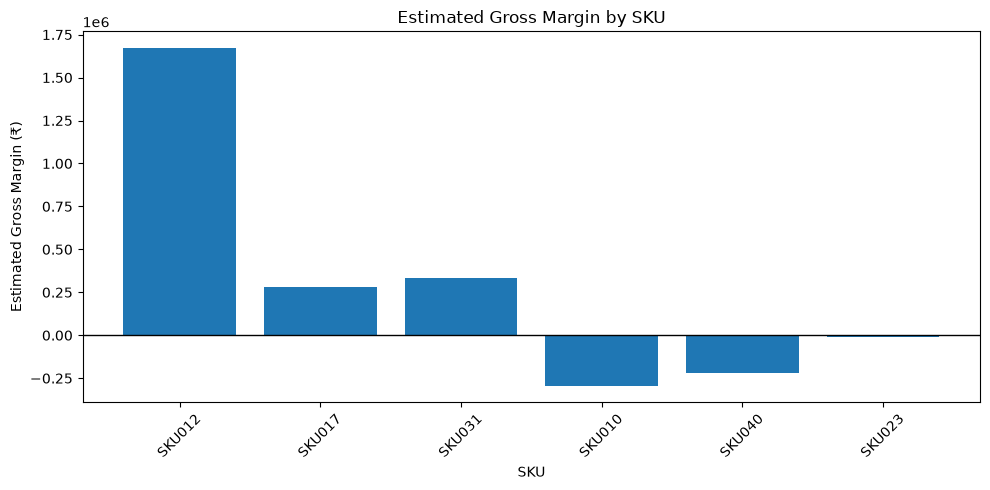

In [15]:
plt.figure(figsize=(10, 5))

plt.bar(
    replenishment_list["SKU"],
    replenishment_list["Estimated_Gross_Margin"]
)

plt.axhline(y=0, color="black", linewidth=1)

plt.title("Estimated Gross Margin by SKU")
plt.xlabel("SKU")
plt.ylabel("Estimated Gross Margin (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Inventory Recommendations — Key Findings

### Demand and Inventory Risk
- Inventory snapshot date: December 1, 2025.
- Demand calculations use 100 complete historical weeks ending November 30, 2025.
- Five SKUs have estimated lead-time demand shortfalls.
- Total estimated shortfall: 485.98 units.
- Six SKUs have positive recommended replenishment quantities.

### Replenishment Summary
- Total recommended additional units: 705.29.
- Estimated replenishment cost: ₹30,27,568.74.
- Estimated revenue potential: ₹48,02,911.61.
- Estimated gross margin: ₹17,75,342.87.

### Business Insights
- SKU012 has the largest positive estimated gross margin.
- SKU010, SKU040, and SKU023 have negative estimated gross margins.
- These products require pricing or cost review before replenishment decisions.

### Business Recommendation
Use demand, supplier lead time, current stock, incoming orders, safety stock, and product profitability to support inventory planning.

### Assumptions and Limitations
- Demand is estimated using historical average weekly sales.
- All incoming orders are assumed to contribute to stock position.
- Financial estimates assume recommended units are sold at listed selling prices.
- Revenue and gross margin are potential estimates, not realized financial results.
- Recommendations should be validated against current inventory and supplier delivery schedules.

In [17]:
sales["Date"] = pd.to_datetime(sales["Date"])
snapshot_date = latest_date

sales_before_snapshot = sales[
    sales["Date"] <= snapshot_date
].copy()

print("Inventory Snapshot:", snapshot_date)
print("Sales Data Until:", sales_before_snapshot["Date"].max())
print("Records Available:", len(sales_before_snapshot))

Inventory Snapshot: 2025-12-01 00:00:00
Sales Data Until: 2025-12-01 00:00:00
Records Available: 35050


In [18]:
weekly_sales_before_snapshot = (
    sales_before_snapshot
    .groupby([
        "SKU",
        pd.Grouper(key="Date", freq="W-SUN")
    ])["Units_Sold"]
    .sum()
    .reset_index()
)

# Keep only fully completed weeks before the snapshot
weekly_sales_before_snapshot = weekly_sales_before_snapshot[
    weekly_sales_before_snapshot["Date"] <= "2025-11-30"
].copy()

print("Weekly Data Shape:", weekly_sales_before_snapshot.shape)
print(weekly_sales_before_snapshot.tail())

Weekly Data Shape: (5000, 3)
         SKU       Date  Units_Sold
5044  SKU050 2025-11-02          32
5045  SKU050 2025-11-09          46
5046  SKU050 2025-11-16          40
5047  SKU050 2025-11-23          41
5048  SKU050 2025-11-30          30


In [19]:
average_demand = (
    weekly_sales_before_snapshot
    .groupby("SKU")["Units_Sold"]
    .mean()
    .reset_index()
)

average_demand = average_demand.rename(
    columns={"Units_Sold": "Avg_Weekly_Demand"}
)

print(average_demand.head(10))

      SKU  Avg_Weekly_Demand
0  SKU001             101.21
1  SKU002              71.73
2  SKU003              40.69
3  SKU004              32.39
4  SKU005             117.39
5  SKU006              46.04
6  SKU007             174.52
7  SKU008             114.94
8  SKU009              75.04
9  SKU010             119.76


In [20]:
recommendation_data = matched_inventory.drop(
    columns=["Avg_Weekly_Demand", "Daily_Demand",
             "Lead_Time_Demand", "Stock_Position",
             "Estimated_Shortfall", "Target_Stock",
             "Recommended_Additional_Units"],
    errors="ignore"
).merge(
    average_demand,
    on="SKU",
    how="left"
)

recommendation_data["Daily_Demand"] = (
    recommendation_data["Avg_Weekly_Demand"] / 7
)

recommendation_data["Lead_Time_Demand"] = (
    recommendation_data["Daily_Demand"]
    * recommendation_data["Lead_Time_Days"]
)

print(
    recommendation_data[
        ["SKU", "Avg_Weekly_Demand", "Lead_Time_Days",
         "Lead_Time_Demand"]
    ].head(10).round(2)
)

      SKU  Avg_Weekly_Demand  Lead_Time_Days  Lead_Time_Demand
0  SKU001             101.21               4             57.83
1  SKU002              71.73               3             30.74
2  SKU003              40.69               3             17.44
3  SKU004              32.39               6             27.76
4  SKU005             117.39               6            100.62
5  SKU006              46.04              13             85.50
6  SKU007             174.52               8            199.45
7  SKU008             114.94               3             49.26
8  SKU009              75.04               7             75.04
9  SKU010             119.76              13            222.41


In [21]:
recommendation_data["Stock_Position"] = (
    recommendation_data["Current_Stock"]
    + recommendation_data["On_Order"]
)

recommendation_data["Estimated_Shortfall"] = (
    recommendation_data["Lead_Time_Demand"]
    - recommendation_data["Stock_Position"]
).clip(lower=0)

shortfall_products = recommendation_data[
    recommendation_data["Estimated_Shortfall"] > 0
].copy()

print(
    shortfall_products[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Demand",
            "Estimated_Shortfall"
        ]
    ].round(2)
)

print(
    "\nNumber of SKUs with estimated shortfall:",
    len(shortfall_products)
)

       SKU  Stock_Position  Lead_Time_Demand  Estimated_Shortfall
9   SKU010             153            222.41                69.41
11  SKU012             107            314.62               207.62
16  SKU017             121            170.69                49.69
30  SKU031             133            245.92               112.92
39  SKU040              96            141.34                45.34

Number of SKUs with estimated shortfall: 5


In [22]:
recommendation_data["Target_Stock"] = (
    recommendation_data["Lead_Time_Demand"]
    + recommendation_data["Safety_Stock"]
)

recommendation_data["Recommended_Additional_Units"] = (
    recommendation_data["Target_Stock"]
    - recommendation_data["Stock_Position"]
).clip(lower=0)

replenishment_list = recommendation_data[
    recommendation_data["Recommended_Additional_Units"] > 0
].copy()

replenishment_list = replenishment_list.sort_values(
    by="Recommended_Additional_Units",
    ascending=False
)

print(
    replenishment_list[
        [
            "SKU",
            "Stock_Position",
            "Lead_Time_Demand",
            "Safety_Stock",
            "Recommended_Additional_Units"
        ]
    ].round(2)
)

print(
    "\nTotal Recommended Additional Units:",
    round(replenishment_list["Recommended_Additional_Units"].sum(), 2)
)

       SKU  Stock_Position  Lead_Time_Demand  Safety_Stock  \
11  SKU012             107            314.62            16   
16  SKU017             121            170.69           108   
30  SKU031             133            245.92            28   
9   SKU010             153            222.41            22   
39  SKU040              96            141.34            36   
22  SKU023             209            178.30            41   

    Recommended_Additional_Units  
11                        223.62  
16                        157.69  
30                        140.92  
9                          91.41  
39                         81.34  
22                         10.30  

Total Recommended Additional Units: 705.29


In [23]:
replenishment_list = replenishment_list.drop(
    columns=[
        "Cost_Price",
        "Selling_Price",
        "Estimated_Replenishment_Cost"
    ],
    errors="ignore"
)

replenishment_list = replenishment_list.merge(
    sku_master[["SKU", "Cost_Price", "Selling_Price"]],
    on="SKU",
    how="left"
)

replenishment_list["Estimated_Replenishment_Cost"] = (
    replenishment_list["Recommended_Additional_Units"]
    * replenishment_list["Cost_Price"]
)

print(
    replenishment_list[
        [
            "SKU",
            "Recommended_Additional_Units",
            "Cost_Price",
            "Estimated_Replenishment_Cost"
        ]
    ].round(2)
)

print(
    "\nTotal Estimated Replenishment Cost: ₹",
    round(
        replenishment_list["Estimated_Replenishment_Cost"].sum(),
        2
    )
)

      SKU  Recommended_Additional_Units  Cost_Price  \
0  SKU012                        223.62     1256.89   
1  SKU017                        157.69     6703.26   
2  SKU031                        140.92     6300.65   
3  SKU010                         91.41     3889.06   
4  SKU040                         81.34     5169.07   
5  SKU023                         10.30     2484.54   

   Estimated_Replenishment_Cost  
0                     281069.33  
1                    1057046.65  
2                     887905.60  
3                     355504.53  
4                     420444.77  
5                      25597.86  

Total Estimated Replenishment Cost: ₹ 3027568.74


In [24]:
replenishment_list["Estimated_Revenue"] = (
    replenishment_list["Recommended_Additional_Units"]
    * replenishment_list["Selling_Price"]
)

replenishment_list["Estimated_Gross_Margin"] = (
    replenishment_list["Recommended_Additional_Units"]
    * (
        replenishment_list["Selling_Price"]
        - replenishment_list["Cost_Price"]
    )
)

print(
    replenishment_list[
        [
            "SKU",
            "Estimated_Revenue",
            "Estimated_Gross_Margin"
        ]
    ].round(2)
)

print(
    "\nTotal Estimated Revenue: ₹",
    round(replenishment_list["Estimated_Revenue"].sum(), 2)
)

print(
    "Total Estimated Gross Margin: ₹",
    round(replenishment_list["Estimated_Gross_Margin"].sum(), 2)
)

      SKU  Estimated_Revenue  Estimated_Gross_Margin
0  SKU012         1963267.80              1682198.47
1  SKU017         1336800.70               279754.06
2  SKU031         1228273.76               340368.16
3  SKU010           60647.83              -294856.70
4  SKU040          199325.05              -221119.72
5  SKU023           14596.47               -11001.39

Total Estimated Revenue: ₹ 4802911.61
Total Estimated Gross Margin: ₹ 1775342.87


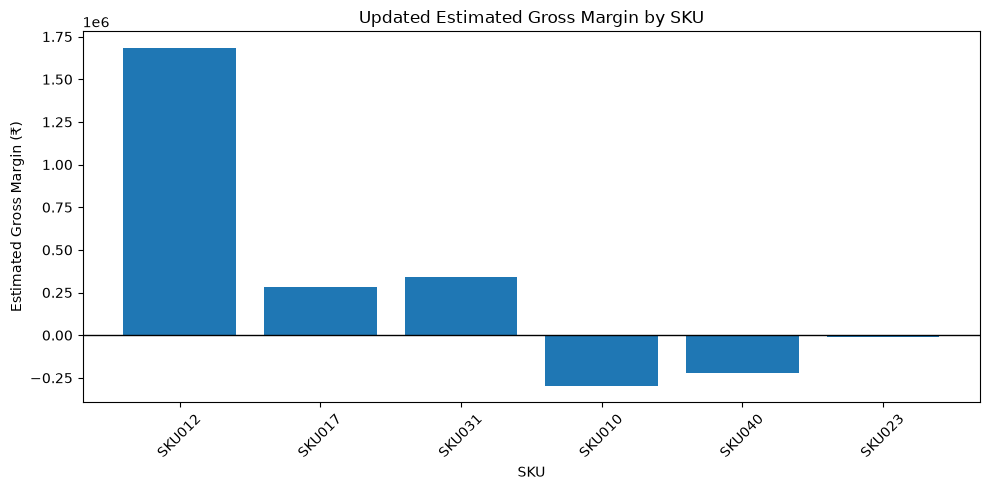

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    replenishment_list["SKU"],
    replenishment_list["Estimated_Gross_Margin"]
)

plt.axhline(y=0, color="black", linewidth=1)

plt.title("Updated Estimated Gross Margin by SKU")
plt.xlabel("SKU")
plt.ylabel("Estimated Gross Margin (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [26]:
print("Total recommendation rows:", len(replenishment_list))

print(
    "Duplicate SKUs:",
    replenishment_list["SKU"].duplicated().sum()
)

print(
    "Missing values:",
    replenishment_list[
        [
            "SKU",
            "Recommended_Additional_Units",
            "Cost_Price",
            "Selling_Price",
            "Estimated_Replenishment_Cost",
            "Estimated_Revenue",
            "Estimated_Gross_Margin"
        ]
    ].isnull().sum().sum()
)

print("\nFinal Recommendation Table:")
display(
    replenishment_list[
        [
            "SKU",
            "Recommended_Additional_Units",
            "Estimated_Replenishment_Cost",
            "Estimated_Revenue",
            "Estimated_Gross_Margin"
        ]
    ].round(2)
)

Total recommendation rows: 6
Duplicate SKUs: 0
Missing values: 0

Final Recommendation Table:


,SKU,Recommended_Additional_Units,Estimated_Replenishment_Cost,Estimated_Revenue,Estimated_Gross_Margin
0,SKU012,223.62,281069.33,1963267.80,1682198.47
1,SKU017,157.69,1057046.65,1336800.70,279754.06
2,SKU031,140.92,887905.60,1228273.76,340368.16
3,SKU010,91.41,355504.53,60647.83,-294856.70
4,SKU040,81.34,420444.77,199325.05,-221119.72
5,SKU023,10.30,25597.86,14596.47,-11001.39
